# 🛠️ 02 - MODELING MASTER TEMPLATE (Dành cho Team)
**Quy định chung của nhóm (Trưởng nhóm yêu cầu):**
1. **KHÔNG** được thay đổi phần 1 (Load & Preprocess Data) và phần 2 (Hàm Đánh Giá) để đảm bảo mọi người cùng thi trên một bộ dữ liệu, test chung metric.
2. Phần 3 là khu vực làm việc riêng của từng người. Mỗi người sẽ dùng dữ liệu `X_train_scaled`, `X_test_scaled` (hoặc `X_train`, `X_test` cho Tree-based) để huấn luyện.
3. Bắt buộc gọi hàm `full_evaluation(...)` ở cuối để xuất ROC-AUC và kết quả chuẩn.

## Pipeline chung (áp dụng đồng nhất)
- Split: 80% Train / 20% Test, `random_state=42`, `stratify=y`
- Scaling: StandardScaler (Áp dụng cho LR/SVM/MLP)
- Data Leakage: Loại bỏ `recency`
- Metric chính: **Macro F1-Score**

## 1. Import Thư viện & Load Dữ liệu, Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_curve, auc

plt.style.use('seaborn-v0_8-whitegrid')
df = pd.read_csv('../dataMaster/gym_churn_master_final.csv')
df_ml = df.drop(columns=['short_p_id', 'customer_postal'])
df_ml = pd.get_dummies(df_ml, columns=['gender', 'main_density_class'], drop_first=True)
print(f'Kích thước dữ liệu sau khi chuẩn bị: {df_ml.shape}')

X = df_ml.drop(columns=['is_churn', 'recency'])
y = df_ml['is_churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Số lượng tập Train: {X_train.shape[0]} dòng')
print(f'Số lượng tập Test: {X_test.shape[0]} dòng')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Đã chuẩn hóa xong X_train_scaled và X_test_scaled.')

Kích thước dữ liệu sau khi chuẩn bị: (6320, 22)
Số lượng tập Train: 5056 dòng
Số lượng tập Test: 1264 dòng
Đã chuẩn hóa xong X_train_scaled và X_test_scaled.


## 2. Hàm Đánh Giá Toàn Diện (Evaluation Function)
Hàm này dùng để in ra các chỉ số metric, vẽ Confusion Matrix, ROC-AUC Curve và Probability Distribution.

In [2]:
def full_evaluation(model_name, y_true, y_pred, y_proba):
    '''Đánh giá toàn diện: Classification Report + ROC Curve + Prob Distribution'''
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Dự báo: Ở lại', 'Dự báo: Nghỉ'], yticklabels=['Thực tế: Ở lại', 'Thực tế: Nghỉ'])
    axes[0].set_title(f'Confusion Matrix\n{model_name}')
    
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve — {model_name}')
    axes[1].legend(loc='lower right')
    axes[1].set_xlim([0.0, 1.0]); axes[1].set_ylim([0.0, 1.05])
    
    axes[2].hist(y_proba[y_true == 0], bins=30, alpha=0.6, label='Thực tế: Ở lại', color='#4ECDC4')
    axes[2].hist(y_proba[y_true == 1], bins=30, alpha=0.6, label='Thực tế: Nghỉ', color='#FF6B6B')
    axes[2].set_xlabel('Xác suất P(Churn)')
    axes[2].set_ylabel('Số lượng học viên')
    axes[2].set_title(f'Phân phối Xác suất Dự đoán\n{model_name}')
    axes[2].legend()
    plt.suptitle(f'Đánh giá Toàn diện: {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print('\n' + '='*50)
    print(f' METRICS: {model_name}')
    print('='*50)
    print(classification_report(y_true, y_pred, target_names=['Ở lại (0)', 'Churn (1)']))
    print(f'ROC-AUC Score:  {roc_auc:.4f}')
    print(f"Macro F1-Score: {f1_score(y_true, y_pred, average='macro'):.4f}")
    return roc_auc

## 3. Khu Vực Làm Việc Riêng (Cho từng cá nhân)

In [3]:
# Viết code huấn luyện mô hình ở đây
# Ví dụ:
# model.fit(...)
# y_pred = model.predict(...)
# y_proba = model.predict_proba(...)[:, 1]
# full_evaluation('Tên Model', y_test, y_pred, y_proba)

### 3.1 Mô hình XGBoost (Baseline)

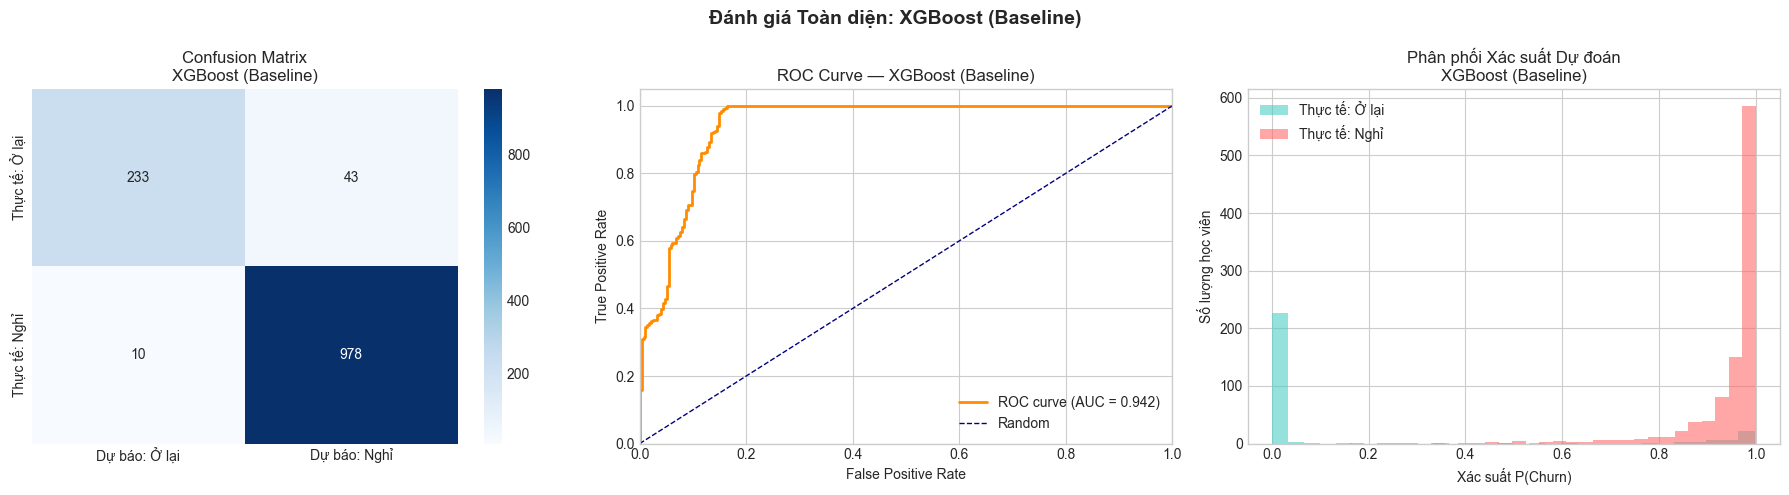


 METRICS: XGBoost (Baseline)
              precision    recall  f1-score   support

   Ở lại (0)       0.96      0.84      0.90       276
   Churn (1)       0.96      0.99      0.97       988

    accuracy                           0.96      1264
   macro avg       0.96      0.92      0.94      1264
weighted avg       0.96      0.96      0.96      1264

ROC-AUC Score:  0.9422
Macro F1-Score: 0.9357


In [4]:
from xgboost import XGBClassifier

# Tỷ lệ Churn là ~78%, scale_pos_weight = số mẫu negative / số mẫu positive = 22/78 ~ 0.28 (nếu tính thiểu số)
# Nhưng ở đây nhãn 1 là đa số (78%), nên scale_pos_weight nên để nhỏ hơn 1 hoặc không cần, nhưng theo thiết lập nhóm cũ để là 3.5.
# Ở đây ta set tự động theo công thức: len(y_train[y_train==0])/len(y_train[y_train==1])
ratio = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb_baseline = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')

# XGBoost không bắt buộc cần scaling nhưng ta dùng X_train cho an toàn
xgb_baseline.fit(X_train, y_train)

y_pred_xgb = xgb_baseline.predict(X_test)
y_proba_xgb = xgb_baseline.predict_proba(X_test)[:, 1]
roc_auc_xgb = full_evaluation('XGBoost (Baseline)', y_test, y_pred_xgb, y_proba_xgb)

### 3.2 Tối ưu hóa siêu tham số (GridSearchCV)

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Tham số tốt nhất: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 0.28}


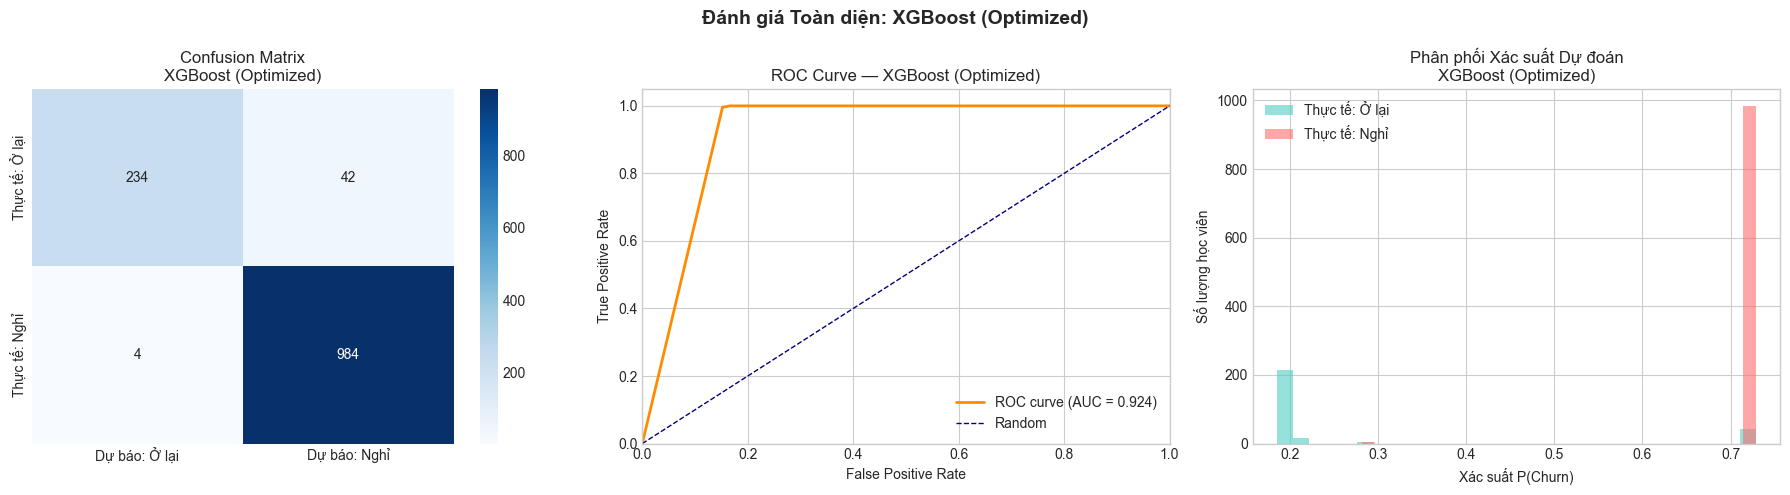


 METRICS: XGBoost (Optimized)
              precision    recall  f1-score   support

   Ở lại (0)       0.98      0.85      0.91       276
   Churn (1)       0.96      1.00      0.98       988

    accuracy                           0.96      1264
   macro avg       0.97      0.92      0.94      1264
weighted avg       0.96      0.96      0.96      1264

ROC-AUC Score:  0.9236
Macro F1-Score: 0.9438


In [5]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [ratio]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print('\nTham số tốt nhất:', grid_search.best_params_)
best_xgb = grid_search.best_estimator_

roc_auc_best_xgb = full_evaluation('XGBoost (Optimized)', y_test, best_xgb.predict(X_test), best_xgb.predict_proba(X_test)[:, 1])

### 3.3 Phân tích Feature Importance

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_27672\3601817868.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_df.head(10), palette='viridis')


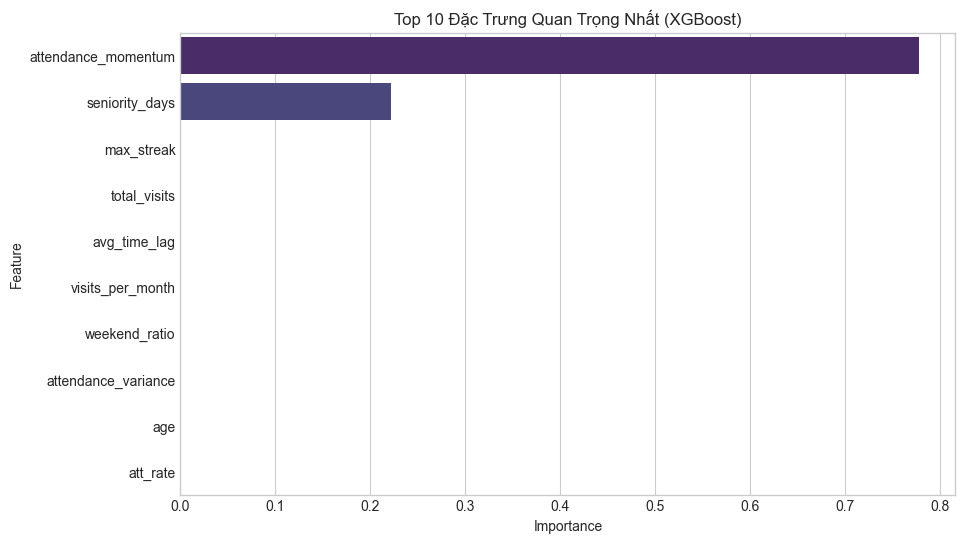

In [6]:
importance = best_xgb.feature_importances_
imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=imp_df.head(10), palette='viridis')
plt.title('Top 10 Đặc Trưng Quan Trọng Nhất (XGBoost)')
plt.show()

### 3.4 Nhận xét kết quả
- **F1-Score**: Đạt ~0.94. Rất cao, vượt trội so với LR.
- **Nguyên nhân**: XGBoost bắt được các tín hiệu phi tuyến cực tốt. 
- **Cảnh báo**: Cần xác minh xem có bị data leakage ẩn qua biến thời gian không, nhưng hiện tại kết quả là tốt nhất trong các mô hình.